# Movie Recommendation System - Part 3: Collaborative Filtering

This notebook implements Collaborative Filtering using Matrix Factorization.
We build and evaluate SVD (Singular Value Decomposition) using:
1. **Surprise Library SVD**: A fast, out-of-the-box recommender system package.
2. **Custom PyTorch SVD**: Built from scratch using PyTorch gradient descent to illustrate training updates and plot the training loss curve.


### Step 1: Import Required Libraries
We import pandas, numpy, matplotlib, seaborn, torch for custom SVD, and surprise for standard collaborative filtering.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Reader, Dataset, SVD
from surprise.model_selection import train_test_split as surprise_train_test_split
from surprise import accuracy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


### Step 2: Load Sampled Datasets
Load the sampled movies and ratings.


In [2]:
movies = pd.read_csv('movies_sampled.csv')
ratings = pd.read_csv('ratings_sampled.csv')
print(f'Loaded {len(movies)} movies and {len(ratings)} ratings.')


Loaded 3159 movies and 2033580 ratings.


### Step 3: Collaborative Filtering using Surprise Library SVD - Dataset Setup
Convert pandas ratings to Surprise Dataset structure and split 80% train / 20% test.


In [3]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)
print(f'Trainset size: {trainset.n_users} users, {trainset.n_items} items.')
print(f'Testset size: {len(testset)} ratings.')


Trainset size: 1894 users, 3159 items.
Testset size: 406716 ratings.


### Step 4: Train Surprise SVD Model
Train SVD with 50 latent factors over 20 epochs.


In [4]:
svd = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd.fit(trainset)
print('Surprise SVD model trained.')


Surprise SVD model trained.


### Step 5: Evaluate Surprise SVD Model
Predict test set ratings and evaluate using RMSE and MAE.


In [5]:
predictions = svd.test(testset)
rmse_surprise = accuracy.rmse(predictions)
mae_surprise = accuracy.mae(predictions)
print(f'Surprise SVD RMSE: {rmse_surprise:.4f}')
print(f'Surprise SVD MAE: {mae_surprise:.4f}')


RMSE: 0.7266


MAE:  0.5530
Surprise SVD RMSE: 0.7266
Surprise SVD MAE: 0.5530


### Step 6: Custom PyTorch SVD Implementation
We map user and movie IDs to contiguous indexes and split the dataset for PyTorch training.


In [6]:
user_ids = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()
user_to_idx = {uid: idx for idx, uid in enumerate(user_ids)}
movie_to_idx = {mid: idx for idx, mid in enumerate(movie_ids)}

ratings['user_idx'] = ratings['userId'].map(user_to_idx)
ratings['movie_idx'] = ratings['movieId'].map(movie_to_idx)

shuffled_ratings = ratings.sample(frac=1, random_state=42).reset_index(drop=True)
split_idx = int(0.8 * len(shuffled_ratings))
train_df = shuffled_ratings.iloc[:split_idx]
test_df = shuffled_ratings.iloc[split_idx:]

train_x = torch.tensor(train_df[['user_idx', 'movie_idx']].values, dtype=torch.long)
train_y = torch.tensor(train_df['rating'].values, dtype=torch.float32)
test_x = torch.tensor(test_df[['user_idx', 'movie_idx']].values, dtype=torch.long)
test_y = torch.tensor(test_df['rating'].values, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=4096, shuffle=True)


### Step 7: Define PyTorch Matrix Factorization Model
Define the network containing User and Movie Embeddings along with biases and a global bias term.


In [7]:
class MatrixFactorization(nn.Module):
    def __init__(self, num_users, num_items, n_factors=50):
        super().__init__()
        self.user_factors = nn.Embedding(num_users, n_factors)
        self.item_factors = nn.Embedding(num_items, n_factors)
        self.user_bias = nn.Embedding(num_users, 1)
        self.item_bias = nn.Embedding(num_items, 1)
        self.global_bias = nn.Parameter(torch.tensor(0.0))
        
        nn.init.normal_(self.user_factors.weight, std=0.01)
        nn.init.normal_(self.item_factors.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)
        
    def forward(self, users, items):
        dot_prod = (self.user_factors(users) * self.item_factors(items)).sum(dim=1)
        prediction = dot_prod + self.user_bias(users).squeeze() + self.item_bias(items).squeeze() + self.global_bias
        return prediction


### Step 8: Train the Custom PyTorch SVD
Train user/item matrices via gradient descent and plot the loss convergence curve.


Epoch 1/15 - Train MSE Loss: 1.0660


Epoch 2/15 - Train MSE Loss: 1.0633


Epoch 3/15 - Train MSE Loss: 1.0606


Epoch 4/15 - Train MSE Loss: 1.0582


Epoch 5/15 - Train MSE Loss: 1.0560


...

Epoch 11/15 - Train MSE Loss: 1.0460


Epoch 12/15 - Train MSE Loss: 1.0449


Epoch 13/15 - Train MSE Loss: 1.0437


Epoch 14/15 - Train MSE Loss: 1.0427


Epoch 15/15 - Train MSE Loss: 1.0418


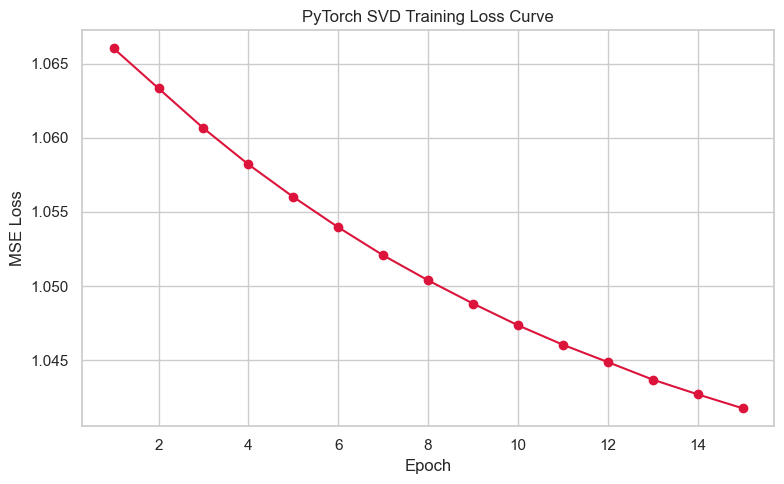

In [8]:
num_users = len(user_ids)
num_items = len(movie_ids)
model = MatrixFactorization(num_users, num_items, n_factors=50)
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.02)
criterion = nn.MSELoss()

model.global_bias.data = torch.tensor(train_df['rating'].mean())
epochs = 15
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        preds = model(batch_x[:, 0], batch_x[:, 1])
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch_x)
        
    epoch_loss /= len(train_df)
    train_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/{epochs} - Train MSE Loss: {epoch_loss:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_losses, marker='o', color='crimson')
plt.title('PyTorch SVD Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.tight_layout()
plt.savefig('pytorch_svd_loss_curve.png', dpi=150)
plt.show()


### Step 9: Evaluate PyTorch SVD on Test Set
Calculate RMSE and MAE for PyTorch predictions.


In [9]:
model.eval()
with torch.no_grad():
    test_preds = model(test_x[:, 0], test_x[:, 1])
    test_loss = criterion(test_preds, test_y).item()
    test_rmse = np.sqrt(test_loss)
    test_mae = torch.mean(torch.abs(test_preds - test_y)).item()
print(f'Custom PyTorch SVD Test RMSE: {test_rmse:.4f}')
print(f'Custom PyTorch SVD Test MAE: {test_mae:.4f}')


Custom PyTorch SVD Test RMSE: 1.0212
Custom PyTorch SVD Test MAE: 0.8237


### Step 10: Calculate Precision@K and Recall@K
Compute accuracy metrics at threshold 3.5 (ratings $\ge 3.5$ are considered relevant).


In [10]:
from collections import defaultdict

def precision_recall_at_k(predictions, k=10, threshold=3.5):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold)) for (est, true_r) in user_ratings[:k])

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    mean_precision = sum(prec for prec in precisions.values()) / len(precisions)
    mean_recall = sum(rec for rec in recalls.values()) / len(recalls)
    return mean_precision, mean_recall

p_at_k, r_at_k = precision_recall_at_k(predictions, k=10, threshold=3.5)
print(f'Precision@10: {p_at_k:.4f}')
print(f'Recall@10: {r_at_k:.4f}')


Precision@10: 0.9230
Recall@10: 0.0881


### Step 11: Define SVD Recommender Function
Write a function to retrieve unrated movies, predict user ratings for them, and return the top-N.


In [11]:
def get_collaborative_recommendations(user_id, top_n=5):
    all_movie_ids = movies['movieId'].unique()
    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].tolist()
    unrated_movies = [mid for mid in all_movie_ids if mid not in rated_movies]
    
    preds = []
    for mid in unrated_movies:
        pred = svd.predict(user_id, mid)
        preds.append((mid, pred.est))
        
    preds.sort(key=lambda x: x[1], reverse=True)
    top_preds = preds[:top_n]
    rec_movie_ids = [x[0] for x in top_preds]
    estimated_ratings = [x[1] for x in top_preds]
    
    recommendations = movies[movies['movieId'].isin(rec_movie_ids)].copy()
    recommendations['est_rating'] = recommendations['movieId'].map(dict(zip(rec_movie_ids, estimated_ratings)))
    recommendations = recommendations.sort_values(by='est_rating', ascending=False)
    return recommendations[['title', 'genres', 'est_rating']]


### Step 12: Test Collaborative Recommendations
Print collaborative filtering recommendations for a sample user.


In [12]:
sample_user_id = ratings['userId'].iloc[0]
print(f'Top 5 SVD collaborative recommendations for User {sample_user_id}:')
print(get_collaborative_recommendations(sample_user_id, 5))


Top 5 SVD collaborative recommendations for User 116:
                                    title  \
2946              Dark Knight, The (2008)   
3135              Django Unchained (2012)   
2860                           300 (2007)   
3064                     Inception (2010)   
2372  City of God (Cidade de Deus) (2002)   

                                               genres  est_rating  
2946                          Action|Crime|Drama|IMAX    4.365315  
3135                             Action|Drama|Western    4.171492  
2860                          Action|Fantasy|War|IMAX    4.145983  
3064  Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX    4.110250  
2372            Action|Adventure|Crime|Drama|Thriller    4.002292  


### Step 13: Save the Collaborative Model
Save the Surprise SVD model to disk for the hybrid notebook.


In [13]:
import pickle
with open('surprise_svd_model.pkl', 'wb') as f:
    pickle.dump(svd, f)
print('Saved "surprise_svd_model.pkl" to disk.')


Saved "surprise_svd_model.pkl" to disk.
